In [ ]:
import pandas as pd

url = "https://github.com/Reemaalsharif/Saudi-Data-Internship-Readiness-Map/raw/refs/heads/main/data/saudi_data_jobs_dataset.csv"

df = pd.read_csv(url)
df.head()

,job_id,job_title,company,city,role_type,experience_level,skills,tools,source,job_link,date_collected,notes
0,1,Data Analyst,ALESAYI HOLDING,Jeddah,Data Analyst,Entry level / 3 years,"customer data analysis, operational performanc...","Excel, PowerPoint, dashboards",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Customer experience data analyst role in autom...
1,2,Geological Data Scientist,Maaden Barrick Copper Company,Mahd Adh Dhahab,Data Scientist,Entry level / 2-5 years,"geological data management, data quality manag...","SQL, Python, Power BI, Tableau, relational dat...",LinkedIn,https://sa.linkedin.com/jobs/view/geological-d...,2026-06-30,Mining sector data science role. Focuses on ge...
2,3,Data Analyst,PrimeGate for Communications and IT,Riyadh,Data Analyst,Entry level,"data analysis, insights generation, dashboardi...","SQL, Power BI, Tableau, Looker, Excel, Python,...",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Entry-level data analyst role for Madinaty Sup...
3,4,Analyst Pricing Analytics and Insights,Schneider Electric,Saudi Arabia,Business / Pricing Analytics,Entry level,"pricing analytics, data analysis, data interpr...","data visualization, dashboards, charts, reports",LinkedIn,https://sa.linkedin.com/jobs/view/analyst-pric...,2026-06-30,Entry-level pricing analytics role. Focuses on...
4,5,Power BI Developer,Acuative Middle East,Jeddah,BI / Power BI Developer,Mid-level,"Power BI dashboard development, business intel...","Power BI Desktop, Power BI Service, DAX, Power...",LinkedIn,https://sa.linkedin.com/jobs/view/power-bi-dev...,2026-06-30,Mid-level Power BI Developer role in Jeddah. F...


In [ ]:
df.shape

(25, 12)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["job_link"].duplicated().sum()

np.int64(0)

In [ ]:
df[["job_title", "company"]].duplicated().sum()

np.int64(0)

In [ ]:
df["city"].value_counts()

,count
city,
Riyadh,17
Saudi Arabia,4
Jeddah,3
Mahd Adh Dhahab,1


In [ ]:
df["role_type"].value_counts()

,count
role_type,
Data Analyst,2
Data Scientist,2
Business / Pricing Analytics,1
BI / Power BI Developer,1
Data / AI Analyst,1
Performance / Operations Analytics,1
Fraud / Cybersecurity Analytics,1
Digital Marketing Analytics,1
Product Analytics,1


In [ ]:
df["experience_level"].value_counts()

,count
experience_level,
Mid-level / 3+ years,3
Entry level,3
Internship / Co-op,2
Mid-level,2
Entry level / 0-2 years,2
Entry level / 3 years,1
Entry level / 2-5 years,1
Assistant level / Analyst Program,1
Associate / 3+ years,1


In [ ]:
df["tools"].value_counts()

,count
tools,
"Excel, PowerPoint, dashboards",1
"SQL, Python, Power BI, Tableau, relational databases, Acquire, DataShed, IMDEXHUB, IMAGO, KRUX",1
"SQL, Power BI, Tableau, Looker, Excel, Python, data warehousing, Spark, Hadoop",1
"data visualization, dashboards, charts, reports",1
"Power BI Desktop, Power BI Service, DAX, Power Query, M Language, SQL, Excel, Pivot Tables, Power Pivot, Macros, Power Automate, Python, Git, Azure DevOps, Microsoft 365, REST APIs, SharePoint, Teams, OneDrive",1
"Python, Java, TensorFlow, PyTorch, MATLAB, Tableau, NLP, computer vision",1
"SQL, Python, LLMs, RAG, Generative AI, machine learning, data visualization",1
"Excel, Power BI, SQL, project management tools, statistical tools",1
"Python, pandas, NumPy, databases, Plotly, Dash, Matplotlib, machine learning, API integration, fraud protection platform",1


In [ ]:
tools_patterns = {
    "SQL": r"\bSQL\b",
    "Python": r"\bPython\b",
    "Power BI": r"Power BI",
    "Excel": r"\bExcel\b",
    "Tableau": r"\bTableau\b",
    "DAX": r"\bDAX\b",
    "Power Query": r"Power Query",
    "Machine Learning": r"Machine Learning|machine learning",
    "Generative AI": r"Generative AI|GenAI",
    "R": r"\bR\b",
    "BigQuery": r"\bBigQuery\b",
    "Git": r"\bGit\b",
    "Azure": r"\bAzure\b",
    "AWS": r"\bAWS\b",
    "GCP": r"\bGCP\b"
}

tool_counts = {}

for tool, pattern in tools_patterns.items():
    tool_counts[tool] = df["tools"].str.contains(pattern, case=False, na=False, regex=True).sum()

tool_counts

{'SQL': np.int64(14),
 'Python': np.int64(11),
 'Power BI': np.int64(10),
 'Excel': np.int64(10),
 'Tableau': np.int64(7),
 'DAX': np.int64(1),
 'Power Query': np.int64(1),
 'Machine Learning': np.int64(3),
 'Generative AI': np.int64(3),
 'R': np.int64(3),
 'BigQuery': np.int64(1),
 'Git': np.int64(1),
 'Azure': np.int64(3),
 'AWS': np.int64(2),
 'GCP': np.int64(1)}

In [ ]:
tool_counts_df = pd.DataFrame(
    list(tool_counts.items()),
    columns=["tool", "count"]
).sort_values(by="count", ascending=False)

tool_counts_df

,tool,count
0,SQL,14
1,Python,11
2,Power BI,10
3,Excel,10
4,Tableau,7
8,Generative AI,3
7,Machine Learning,3
9,R,3
12,Azure,3
13,AWS,2


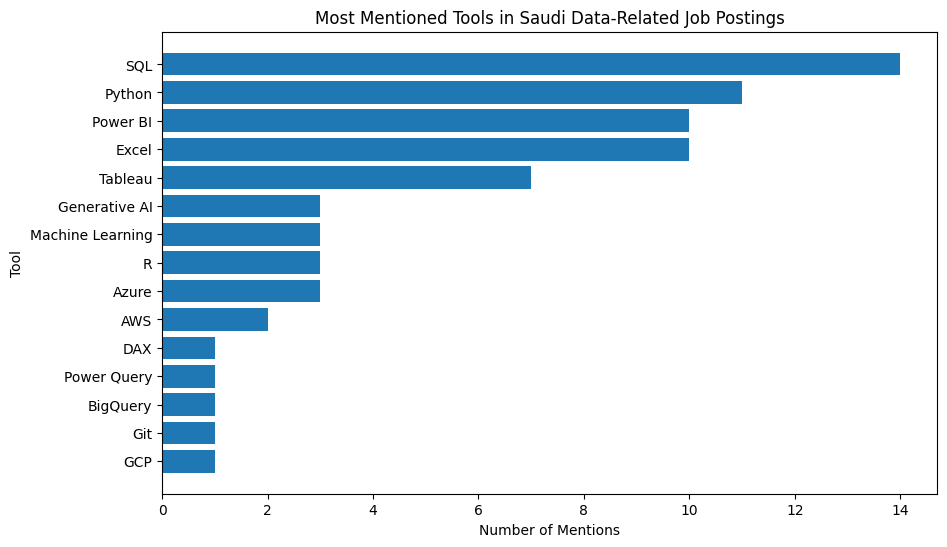

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(tool_counts_df["tool"], tool_counts_df["count"])
plt.xlabel("Number of Mentions")
plt.ylabel("Tool")
plt.title("Most Mentioned Tools in Saudi Data-Related Job Postings")
plt.gca().invert_yaxis()
plt.show()

### Initial Insight: Most Mentioned Tools

From the first 25 Saudi data-related job and internship postings, SQL appeared as the most mentioned tool, followed by Python, Power BI, Excel, and Tableau.

This suggests that the strongest foundation for a Computer Science student interested in Data Science should include SQL, Python, data visualization, and BI/reporting tools.

In [ ]:
city_counts = df["city"].value_counts()

city_counts

,count
city,
Riyadh,17
Saudi Arabia,4
Jeddah,3
Mahd Adh Dhahab,1


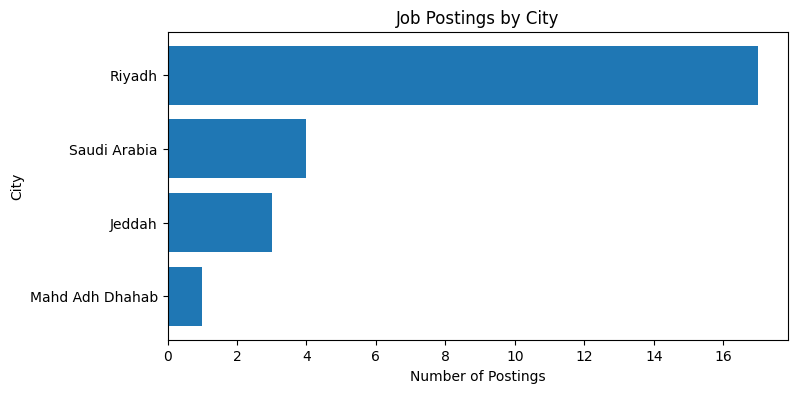

In [ ]:
plt.figure(figsize=(8, 4))
plt.barh(city_counts.index, city_counts.values)
plt.xlabel("Number of Postings")
plt.ylabel("City")
plt.title("Job Postings by City")
plt.gca().invert_yaxis()
plt.show()

### Initial Insight: Job Locations

Most of the collected postings are located in Riyadh, followed by a smaller number in Jeddah and other locations.

Some postings only listed the location as "Saudi Arabia" instead of a specific city. This means the city column will need cleaning later by replacing unclear locations with "Not specified" or checking the original job posting when possible.

In [ ]:
role_counts = df["role_type"].value_counts()

role_counts

,count
role_type,
Data Analyst,2
Data Scientist,2
Business / Pricing Analytics,1
BI / Power BI Developer,1
Data / AI Analyst,1
Performance / Operations Analytics,1
Fraud / Cybersecurity Analytics,1
Digital Marketing Analytics,1
Product Analytics,1


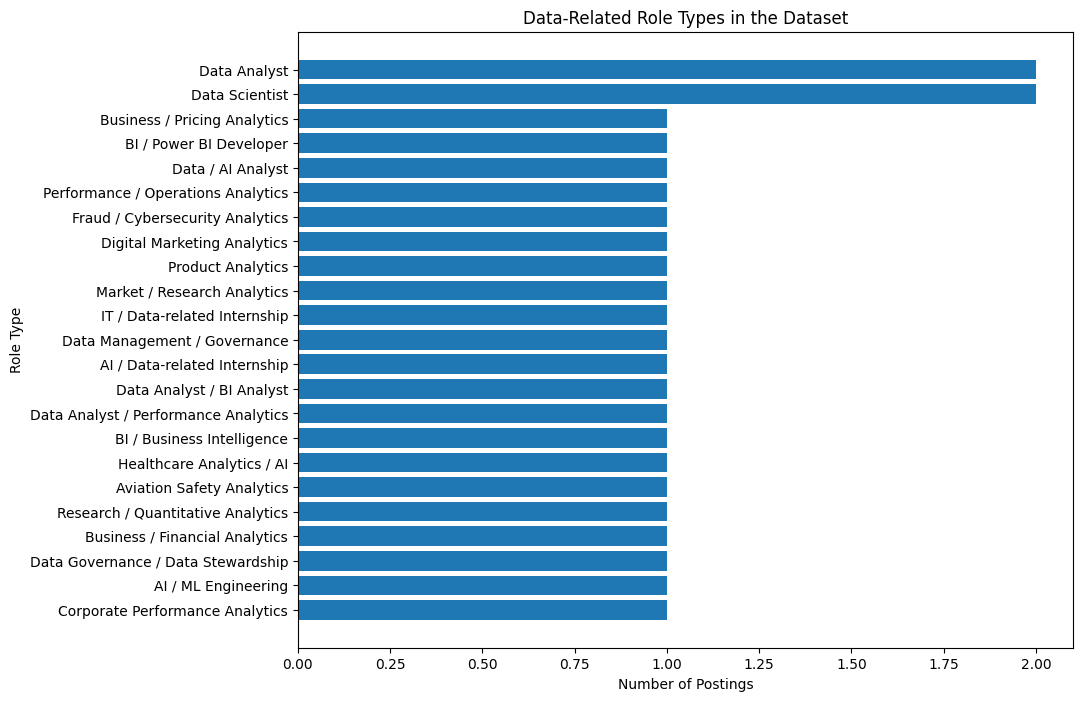

In [ ]:
plt.figure(figsize=(10, 8))
plt.barh(role_counts.index, role_counts.values)
plt.xlabel("Number of Postings")
plt.ylabel("Role Type")
plt.title("Data-Related Role Types in the Dataset")
plt.gca().invert_yaxis()
plt.show()

### Initial Insight: Role Type Diversity

The dataset shows that Saudi data-related opportunities are spread across many different role types, not only "Data Analyst" or "Data Scientist".

This includes roles in BI, product analytics, performance analytics, data governance, AI/ML, research analytics, healthcare analytics, and internship/co-op programs.

This supports the idea that students should not search by job title only, but should also look at the responsibilities, required tools, and skills behind each role.

In [ ]:
experience_counts = df["experience_level"].value_counts()

experience_counts

,count
experience_level,
Mid-level / 3+ years,3
Entry level,3
Internship / Co-op,2
Mid-level,2
Entry level / 0-2 years,2
Entry level / 3 years,1
Entry level / 2-5 years,1
Assistant level / Analyst Program,1
Associate / 3+ years,1


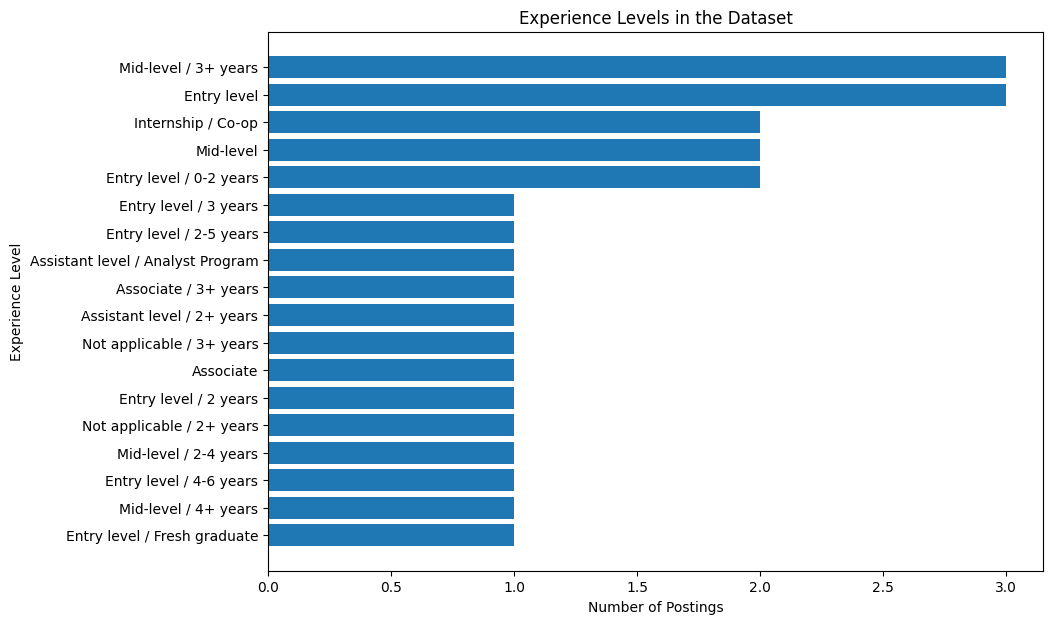

In [ ]:
plt.figure(figsize=(10, 7))
plt.barh(experience_counts.index, experience_counts.values)
plt.xlabel("Number of Postings")
plt.ylabel("Experience Level")
plt.title("Experience Levels in the Dataset")
plt.gca().invert_yaxis()
plt.show()

### Initial Insight: Experience Levels

The experience level column contains detailed and inconsistent labels, such as entry level, internship/co-op, mid-level, and roles with specific year requirements.

This shows that the dataset will need a simplified experience category later, such as:
- Internship / Co-op
- Entry Level
- Mid-Level
- Senior / Manager
- Not Specified

This will make the analysis easier and more useful when building the final readiness roadmap.